In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
from ydata_profiling import ProfileReport
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re
from code_location_interview.assets.magenta_interview.extract import load_artifact
from code_location_interview.assets.magenta_interview.transform import summarize_customer_interactions, add_remaining_binding_flag, aggregate_usage_info, prepare_merged_data


INFO:dagster.builtin:Using deployment of: dev


22:33:52  The selection criterion 'fqn:*' does not match any enabled nodes


/workspaces/data-scientist-at-magenta-walter/src/code_location_interview/code_location_interview/__init__.py:19: ExperimentalWarning: Function `with_source_code_references` is experimental. It may break in future versions, even between dot releases. To mute warnings for experimental functionality, invoke warnings.filterwarnings("ignore", category=dagster.ExperimentalWarning) or use one of the other methods described at https://docs.python.org/3/library/warnings.html#describing-warning-filters.
  all_assets = with_source_code_references(
/workspaces/data-scientist-at-magenta-walter/.pixi/envs/dev/lib/python3.12/site-packages/dagster/_core/definitions/metadata/source_code.py:74: ExperimentalWarning: Class `LocalFileCodeReference` is experimental. It may break in future versions, even between dot releases. To mute warnings for experimental functionality, invoke warnings.filterwarnings("ignore", category=dagster.ExperimentalWarning) or use one of the other methods described at https://docs

`core_data`

| Feature Name           | Description                                                  |
|------------------------|--------------------------------------------------------------|
| rating_account_id      | Unique identifier for the contract account                    |
| customer_id            | Unique identifier for the customer                           |
| age                    | Age of the customer                                          |
| contract_lifetime_days | Total duration of the customer contract in days              |
| remaining_binding_days | Number of days left in the contract binding period - usual binding period is 2 years        |
| has_special_offer      | Indicates if the customer has a special offer      |
| is_magenta1_customer   | Indicates if the customer is part of the Magenta1 program - fedelty program    |
| available_gb           | Amount of mobile data included in the current tariff         |
| gross_mrc              | Gross monthly recurring charge (in euros)                    |
| smartphone_brand       | Brand of the customer’s smartphone                           |
| has_done_upselling     | Whether the customer has already done an upsell in the last 3 years      |


In [3]:
core_data = load_artifact("core_data")
core_data

,rating_account_id,customer_id,age,contract_lifetime_days,remaining_binding_days,has_special_offer,is_magenta1_customer,available_gb,gross_mrc,smartphone_brand,has_done_upselling
0,859783,5.936433,44,647,-637,0,0,30,15.61,iPhone,0
1,601956,3.842443,49,664,152,1,0,50,19.59,Xiaomi,0
2,382208,2.450427,40,746,564,0,0,None,36.84,iPhone,0
3,516423,2.758733,43,1033,65,0,0,30,30.20,iPhone,0
4,790915,1.477295,42,397,-374,0,0,10,15.61,Huawei,0
...,...,...,...,...,...,...,...,...,...,...,...
99995,944120,4.297215,96,1200,-555,1,0,40,32.86,iPhone,0
99996,935086,2.724675,79,1374,-289,1,0,50,59.39,Samsung,0
99997,825005,1.182319,90,1514,91,0,1,40,18.27,Samsung,0
99998,600802,1.738266,80,1528,302,0,0,40,8.98,Huawei,0


`usage_info`

| Feature Name           | Description                                                  |
|------------------------|--------------------------------------------------------------|
| rating_account_id      | Unique identifier for the contract account                    |
| billed_period_month_d  | Billing period (monthly)                                     |
| has_used_roaming       | Indicates if roaming was used during the period            |
| used_gb                | Amount of mobile data used in the billing period (in GB)     |


In [4]:
usage_info = load_artifact("usage_info")
usage_info

,rating_account_id,billed_period_month_d,has_used_roaming,used_gb
0,859783,2024-04-01,1,0.7
1,859783,2024-05-01,0,0.1
2,859783,2024-06-01,0,0.2
3,859783,2024-07-01,0,0.7
4,601956,2024-04-01,1,0.6
...,...,...,...,...
399995,600802,2024-07-01,0,27.4
399996,526456,2024-04-01,1,24.2
399997,526456,2024-05-01,0,39.7
399998,526456,2024-06-01,0,46.5


`customer_interactions`

| Feature Name   | Description                                                              |
|----------------|--------------------------------------------------------------------------|
| customer_id    | Unique identifier for the customer                                       |
| type_subtype   | Category and subtype of the interaction (e.g., tariff change, billing)   |
| n              | Number of interactions of this type in the last 6 months                                |
| days_since_last| Number of days since the last interaction of this type                   |


In [5]:
customer_interactions = load_artifact("customer_interactions")
customer_interactions

,customer_id,type_subtype,n,days_since_last
0,1.479223,produkte&services-tarifwechsel,4,73
1,5.736449,produkte&services-tarifdetails,1,44
2,4.767742,prolongation,2,176
3,4.767742,produkte&services-tarifwechsel,1,89
4,3.868203,prolongation,2,9
...,...,...,...,...
63300,4.758872,produkte&services-tarifwechsel,2,124
63301,3.845211,produkte&services-tarifwechsel,2,82
63302,1.749116,produkte&services-tarifdetails,3,178
63303,5.204978,produkte&services-tarifwechsel,1,100


## 0. Check data types

In [6]:
print(f"core_data dtypes:\n{core_data.dtypes}")
print("""\ncustomer_id has float like values but is of object type, whether or not that is an issue depends on the data type of customer_id in the other tables.
available_gb is also object type but should be numeric if numeric operations are needed (e.g. relative amount of data used = used_gb / available_gb).
smartphone_brand is object type but should be categorical.
""")

print(f"usage_info dtypes:\n{usage_info.dtypes}")
print("billed_period_month_date should be datetime type.\n")

print(f"customer_interactions dtypes:\n{customer_interactions.dtypes}")
print("customer_id is of object type as in table core_data so neither needs to be changed. type_subtype should be categorical.\n")

core_data['available_gb'] = pd.to_numeric(core_data['available_gb'], errors='coerce')
core_data['smartphone_brand'] = core_data['smartphone_brand'].astype('category')

usage_info['billed_period_month_d'] = pd.to_datetime(
    usage_info['billed_period_month_d'], errors='coerce'
)

customer_interactions['type_subtype'] = customer_interactions['type_subtype'].astype('category')

core_data dtypes:
rating_account_id           int64
customer_id                object
age                         int64
contract_lifetime_days      int64
remaining_binding_days      int64
has_special_offer           int64
is_magenta1_customer        int64
available_gb               object
gross_mrc                 float64
smartphone_brand           object
has_done_upselling          int64
dtype: object

customer_id has float like values but is of object type, whether or not that is an issue depends on the data type of customer_id in the other tables.
available_gb is also object type but should be numeric if numeric operations are needed (e.g. relative amount of data used = used_gb / available_gb).
smartphone_brand is object type but should be categorical.

usage_info dtypes:
rating_account_id          int64
billed_period_month_d     object
has_used_roaming           int64
used_gb                  float64
dtype: object
billed_period_month_date should be datetime type.

customer_interact

## 1. Understanding the Data

Before I explore the data in depth, I want to understand the logic of the data and make assumptions about it, whenever more information about the data is required to understand it fully or the randomness of the data introduces problems (in a real world context I would ask someone to clarify, instead of making assumptions).

Since every column in each dataset has already been described above, their individual meaning is clear. I want to focus on investigating implicit assumptions I have about the data due to the data structure and the column descriptions.

1. A contract account can have only one customer, one customer can have multiple contracts (e.g. multiple phones in the household)

2. The age of the customer is the same for each customer id across the dataset, since there is no time variable (e.g. they were 30 in 2024 and 29 in 2023)

3. There is no variable indicating whether someone is upselling or going to upsell in the future in a given period (only for past periods). After asking a team member at magenta whether has_done_upselling is the target variable on which the training should be based upon I will use it as such. For a reals use case I would try to construct a label, that indicates whether someone will upsell in the future and use recent upsells as a feature instead. A recent upsell might be an indicator that a person will likely not upgrade their plan again in the near future regardless of marketing activities. Predicting future upsells can reveal customers, which are likely to use a more expensive plan and can be nudged to upgrade their plan with the appropriate marketing activities.

In [7]:
# 1. Check assumption: one contract account -> one customer, one customer -> multiple contracts
contracts_per_customer = core_data.groupby('customer_id')['rating_account_id'].nunique()
customers_per_contract = core_data.groupby('rating_account_id')['customer_id'].nunique()

print("Contracts per customer (should often be >1 if customers can have multiple contracts):")
print(contracts_per_customer.describe())
print("\nCustomers per contract (should always be 1):")
print(customers_per_contract.value_counts())

# 2. Check assumption: same age for each customer_id
age_variation = core_data.groupby('customer_id')['age'].nunique()
inconsistent_ages = age_variation[age_variation > 1]
print(f"\nNumber of customers with inconsistent ages: {len(inconsistent_ages)}")
if len(inconsistent_ages) > 0:
    print("This assumption is violated. The age seems to be different for each contract, not each customer. Whether or not this column will be used for inference will be discussed later.")

Contracts per customer (should often be >1 if customers can have multiple contracts):
count    58566.000000
mean         1.707475
std          0.903700
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max          9.000000
Name: rating_account_id, dtype: float64

Customers per contract (should always be 1):
customer_id
1    100000
Name: count, dtype: int64

Number of customers with inconsistent ages: 27505
This assumption is violated. The age seems to be different for each contract, not each customer. Whether or not this column will be used for inference will be discussed later.


Before merging tables, check how the foreign keys match up (e.g. are there customer_ids in usage_info that are not in core_data?).

In [8]:
# Check if every rating_account_id in core_data is present in usage_info and vice versa
core_rating_ids = set(core_data['rating_account_id'].unique())
usage_rating_ids = set(usage_info['rating_account_id'].unique())

missing_in_usage = core_rating_ids - usage_rating_ids
missing_in_core = usage_rating_ids - core_rating_ids

print(f"rating_account_id in core_data but missing in usage_info: {len(missing_in_usage)}")
print(f"rating_account_id in usage_info but missing in core_data: {len(missing_in_core)}")

if missing_in_usage:
    print("Example missing in usage_info:", list(missing_in_usage)[:5])
if missing_in_core:
    print("Example missing in core_data:", list(missing_in_core)[:5])


# Check if every customer_id in core_data is present in customer_interactions and vice versa
core_customer_ids = set(core_data['customer_id'].unique())
interact_customer_ids = set(customer_interactions['customer_id'].unique())

missing_in_interactions = core_customer_ids - interact_customer_ids
missing_in_core_customers = interact_customer_ids - core_customer_ids

print(f"\ncustomer_id in core_data but missing in customer_interactions: {len(missing_in_interactions)}")
print(f"customer_id in customer_interactions but missing in core_data: {len(missing_in_core_customers)}")

if missing_in_interactions:
    print("Example missing in customer_interactions:", list(missing_in_interactions)[:5])
if missing_in_core_customers:
    print("Example missing in core_data:", list(missing_in_core_customers)[:5])


rating_account_id in core_data but missing in usage_info: 0
rating_account_id in usage_info but missing in core_data: 0

customer_id in core_data but missing in customer_interactions: 29328
customer_id in customer_interactions but missing in core_data: 12853
Example missing in customer_interactions: ['4.473530', '3.726611', '4.501416', '1.760844', '4.277547']
Example missing in core_data: ['2.622352', '3.961782', '1.634465', '2.496672', '2.140514']


core_data and usage info have the same rating_account_ids. There are customers without interactions (I will assume they have 0 interactions) and interactions of customers that are not present in the core data. Since the interaction data on itself is not very informative I will disregard this data, by making a left merge from core_data to customer_interactions as soon as a merge is required and fill missing data with 0, where it makes sense.

## Data Exploration

In [9]:
core_data = add_remaining_binding_flag(core_data)
core_data.drop(columns=["rating_account_id"]).describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,100000,58566,1.213720,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,100000.0,NaN,NaN,NaN,43.89817,13.804661,18.0,37.0,43.0,49.0,100.0
contract_lifetime_days,100000.0,NaN,NaN,NaN,778.67126,489.947533,7.0,371.0,732.0,1095.25,1825.0
remaining_binding_days,100000.0,NaN,NaN,NaN,-0.82103,344.715683,-730.0,-235.0,0.0,231.0,730.0
has_special_offer,100000.0,NaN,NaN,NaN,0.29908,0.457857,0.0,0.0,0.0,1.0,1.0
is_magenta1_customer,100000.0,NaN,NaN,NaN,0.30127,0.458812,0.0,0.0,0.0,1.0,1.0
available_gb,85963.0,NaN,NaN,NaN,25.080907,17.07909,0.0,10.0,30.0,40.0,50.0
gross_mrc,100000.0,NaN,NaN,NaN,37.415139,19.182963,5.0,20.92,36.84,54.08,70.0
smartphone_brand,100000,5,iPhone,39953,NaN,NaN,NaN,NaN,NaN,NaN,NaN
has_done_upselling,100000.0,NaN,NaN,NaN,0.06884,0.253183,0.0,0.0,0.0,0.0,1.0


Quick Insights:
- available_gb only variable with missing values. Can be left in data for now if we chose an algorithm that can handle missing data (e.g. XGBoost), since imputing it with 0 might be wrong if it is missing at random.
- has_done_upselling is imbalanced (only around 7% positives). This might need to be handled if we try to use a classifier later on, to help the model identify "rare" positive cases. 

In [10]:
customer_interactions.drop(columns=["customer_id"]).describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
type_subtype,63305,4,prolongation,15917,NaN,NaN,NaN,NaN,NaN,NaN,NaN
n,63305.0,NaN,NaN,NaN,1.926214,1.408518,1.0,1.0,1.0,2.0,10.0
days_since_last,63305.0,NaN,NaN,NaN,89.818055,52.10799,0.0,45.0,90.0,135.0,180.0


In [11]:
unique_types = customer_interactions["type_subtype"].unique()
print(f"There are {len(unique_types)} unique interaction type/subtype combinations:")
for item in unique_types:
    print(f" - {item}")

There are 4 unique interaction type/subtype combinations:
 - produkte&services-tarifwechsel
 - produkte&services-tarifdetails
 - prolongation
 - rechnungsanfragen


To use the interaction counts and days_since_last interaction data per type later on as features, it makes sense to pivot the data to have a row for each customer and a column for each type as well as the sum of the interactions and the days_since_last of the most recent interaction.

In [12]:
customer_interactions_pivot = summarize_customer_interactions(customer_interactions)

In [13]:
customer_interactions_pivot.describe(include="all").T

count       mean  \
                    type_subtype                                         
days_since_last     produkte&services-tarifdetails  15895.0  89.453224   
                    produkte&services-tarifwechsel  15609.0  90.221219   
                    prolongation                    15917.0  90.029528   
                    rechnungsanfragen               15884.0  89.575044   
n                   produkte&services-tarifdetails  42091.0   0.721128   
                    produkte&services-tarifwechsel  42091.0   0.712005   
                    prolongation                    42091.0   0.732247   
                    rechnungsanfragen               42091.0   0.731653   
min_days_since_last                                 42091.0  76.105723   
sum_n                                               42091.0   2.897033   

                                                          std  min   25%  \
                    type_subtype                                           
days_since_last     produkte&services-tarifdetails  52.200466  0.0  44.0   
                    produkte&services-tarifwechsel  52.353618  0.0  45.0   
                    prolongation                    51.970919  0.0  45.0   
                    rechnungsanfragen               51.911341  0.0  45.0   
n                   produkte&services-tarifdetails   1.256644  0.0   0.0   
                    produkte&services-tarifwechsel   1.260479  0.0   0.0   
                    prolongation                     1.281560  0.0   0.0   
                    rechnungsanfragen                1.286626  0.0   0.0   
min_days_since_last                                 50.864753  0.0  32.0   
sum_n                                                2.161895  1.0   1.0   

                                                     50%    75%    max  
                    type_subtype                                        
days_since_last     produkte&services-tarifdetails  89.0  134.0  180.0  
                    produkte&services-tarifwechsel  90.0  136.0  180.0  
                    prolongation                    90.0  135.0  180.0  
                    rechnungsanfragen               89.0  135.0  180.0  
n                   produkte&services-tarifdetails   0.0    1.0   10.0  
                    produkte&services-tarifwechsel   0.0    1.0   10.0  
                    prolongation                     0.0    1.0   10.0  
                    rechnungsanfragen                0.0    1.0   10.0  
min_days_since_last                                 70.0  117.0  180.0  
sum_n                                                2.0    4.0   22.0

Quick Insights:
- Every column within days_since_last and n is pretty much identically distributed so probably generated from the same distribution

In [14]:
usage_info.drop(columns="rating_account_id").describe(include="all").T

,count,mean,min,25%,50%,75%,max,std
billed_period_month_d,400000,2024-05-16 12:00:00,2024-04-01 00:00:00,2024-04-23 12:00:00,2024-05-16 12:00:00,2024-06-08 12:00:00,2024-07-01 00:00:00,NaN
has_used_roaming,400000.0,0.299967,0.0,0.0,0.0,1.0,1.0,0.458244
used_gb,400000.0,13.994622,0.0,1.0,5.0,15.0,70.0,18.655648


In [15]:
core_data_usage_info_merged = core_data.merge(
    usage_info,
    on='rating_account_id',
    how='left',
)
core_data_usage_info_merged["leftover_data_gb"] = core_data_usage_info_merged["available_gb"] - core_data_usage_info_merged["used_gb"]

Quick Insights:
- ~30% of contract months have used roaming 

It would be interesting to see how much of the available data (from core_data) was left at the end of the month and see if it depends on whether a person has used roaming or not, since on vacation you might use more data than usually. A person using roaming could therefore be a potential target for an upselling campaign if they use more data than usual.

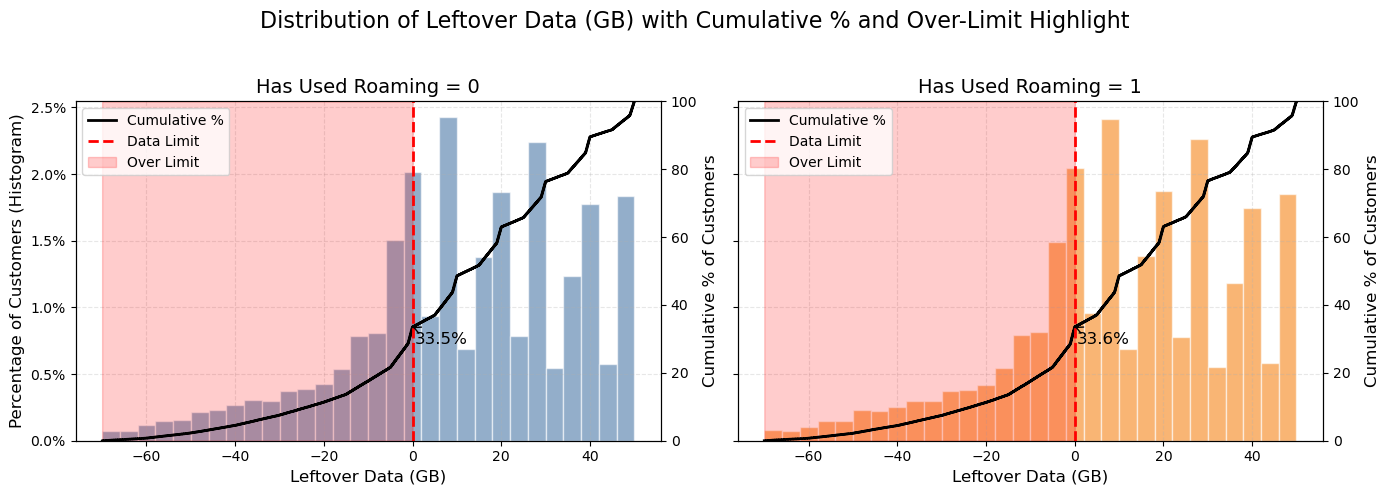

In [16]:
data_limit = 0  # leftover_data_gb = 0 is exactly at the limit

# Unique values for has_used_roaming
roaming_values = sorted(core_data_usage_info_merged["has_used_roaming"].dropna().unique())

fig, axes = plt.subplots(1, len(roaming_values), figsize=(14, 5), sharey=True)

for ax, value in zip(axes, roaming_values):
    subset = core_data_usage_info_merged[core_data_usage_info_merged["has_used_roaming"] == value]
    data = subset["leftover_data_gb"].dropna()
    
    # Histogram as percentage
    n, bins, patches = ax.hist(
        data,
        bins=30,
        color="#4C78A8" if not value else "#F58518",
        edgecolor="white",
        alpha=0.6,
        density=True
    )
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y*100:.1f}%'))
    
    # Cumulative distribution
    sorted_data = np.sort(data)
    cum_percentage = np.arange(1, len(sorted_data)+1) / len(sorted_data) * 100
    
    ax2 = ax.twinx()
    ax2.plot(sorted_data, cum_percentage, color='black', linestyle='-', linewidth=2, label='Cumulative %')
    ax2.axvline(data_limit, color='red', linestyle='--', linewidth=2, label='Data Limit')
    
    # Highlight customers OVER the limit (negative leftover) on the left
    ax2.fill_betweenx(
        cum_percentage,
        x1=sorted_data.min(),
        x2=data_limit,
        color='red',
        alpha=0.2,
        label='Over Limit'
    )
    
    # Annotate cumulative % at data limit
    idx = np.searchsorted(sorted_data, data_limit, side='right') - 1
    if idx >= 0:
        cum_val_at_limit = cum_percentage[idx]
        ax2.annotate(
            f"{cum_val_at_limit:.1f}%",
            xy=(data_limit, cum_val_at_limit),
            xytext=(data_limit + 0.5, cum_val_at_limit - 5),
            arrowprops=dict(facecolor='black', arrowstyle='->'),
            fontsize=12,
            color='black'
        )
    
    ax.set_title(f"Has Used Roaming = {value}", fontsize=14)
    ax.set_xlabel("Leftover Data (GB)", fontsize=12)
    ax.grid(alpha=0.3, linestyle="--")
    
    ax2.set_ylabel("Cumulative % of Customers", fontsize=12)
    ax2.set_ylim(0, 100)
    ax2.legend(loc='upper left')

axes[0].set_ylabel("Percentage of Customers (Histogram)", fontsize=12)
fig.suptitle("Distribution of Leftover Data (GB) with Cumulative % and Over-Limit Highlight", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


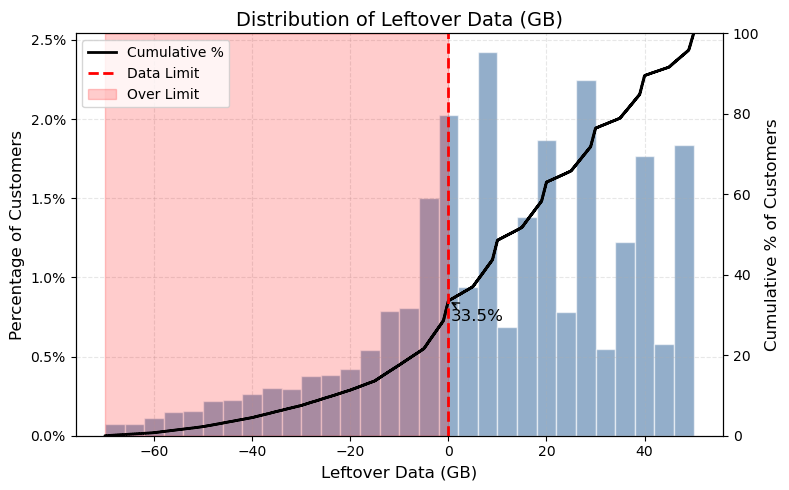

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# Set data limit
data_limit = 0  # leftover_data_gb = 0 is exactly at the limit

# Combine all data (ignore roaming distinction)
data = core_data_usage_info_merged["leftover_data_gb"].dropna()

# Create figure
fig, ax = plt.subplots(figsize=(8, 5))

# Histogram as percentage
n, bins, patches = ax.hist(
    data,
    bins=30,
    color="#4C78A8",
    edgecolor="white",
    alpha=0.6,
    density=True
)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y*100:.1f}%'))

# Cumulative distribution
sorted_data = np.sort(data)
cum_percentage = np.arange(1, len(sorted_data) + 1) / len(sorted_data) * 100

ax2 = ax.twinx()
ax2.plot(sorted_data, cum_percentage, color='black', linestyle='-', linewidth=2, label='Cumulative %')
ax2.axvline(data_limit, color='red', linestyle='--', linewidth=2, label='Data Limit')

# Highlight customers OVER the limit (negative leftover)
ax2.fill_betweenx(
    cum_percentage,
    x1=sorted_data.min(),
    x2=data_limit,
    color='red',
    alpha=0.2,
    label='Over Limit'
)

# Annotate cumulative % at data limit
idx = np.searchsorted(sorted_data, data_limit, side='right') - 1
if idx >= 0:
    cum_val_at_limit = cum_percentage[idx]
    ax2.annotate(
        f"{cum_val_at_limit:.1f}%",
        xy=(data_limit, cum_val_at_limit),
        xytext=(data_limit + 0.5, cum_val_at_limit - 5),
        arrowprops=dict(facecolor='black', arrowstyle='->'),
        fontsize=12,
        color='black'
    )

# Titles and labels
ax.set_title("Distribution of Leftover Data (GB)", fontsize=14)
ax.set_xlabel("Leftover Data (GB)", fontsize=12)
ax.set_ylabel("Percentage of Customers", fontsize=12)
ax.grid(alpha=0.3, linestyle="--")

ax2.set_ylabel("Cumulative % of Customers", fontsize=12)
ax2.set_ylim(0, 100)
ax2.legend(loc='upper left')

plt.tight_layout()
plt.show()


The data seems to be coming from the same distribution and does not depend on whether someone used roaming or not. 
Furthermore 34% of contract months have used up more than the available data on their plan. These could be potential candidates for an upgrade of their data contract.

Since the usage data has 4 entries by rating_account_id (for 4 months of usage), we need to either 

1. pivot the data to result in 1 data point per rating_account_id or 
2. construct aggregate measures from the available data. 

The first option would result in an excessive amount of features, especially if there was data for more than 4 months. So I will continue with option 2 and aggregate the data.

In [18]:
aggregated_usage_info = aggregate_usage_info(core_data, usage_info)
aggregated_usage_info.head()

leftover_data_gb                       used_gb             \
                              mean        std   min  max    mean        std   
rating_account_id                                                             
100002                      -2.625   1.369611  -4.1 -1.1   2.625   1.369611   
100003                     -19.800  19.422839 -37.7  3.6  49.800  19.422839   
100019                       7.250   1.662328   5.4  8.8   2.750   1.662328   
100022                      -9.650   9.685900 -17.3  3.8  29.650   9.685900   
100073                         NaN        NaN   NaN  NaN   0.325   0.394757   

                              has_used_roaming  
                    min   max              sum  
rating_account_id                               
100002              1.1   4.1                3  
100003             26.4  67.7                1  
100019              1.2   4.6                1  
100022             16.2  37.3                0  
100073              0.0   0.8                2

In [19]:
merged_data = prepare_merged_data(core_data, customer_interactions_pivot, aggregated_usage_info)
merged_data.head()

,rating_account_id,customer_id,age,contract_lifetime_days,remaining_binding_days,has_special_offer,is_magenta1_customer,available_gb,gross_mrc,smartphone_brand,...,sum_n,leftover_data_gb_mean,leftover_data_gb_std,leftover_data_gb_min,leftover_data_gb_max,used_gb_mean,used_gb_std,used_gb_min,used_gb_max,has_used_roaming_sum
0,859783,5.936433,44,647,-637,0,0,30.0,15.61,iPhone,...,0.0,29.575,0.320156,29.3,29.9,0.425,0.320156,0.1,0.7,1
1,601956,3.842443,49,664,152,1,0,50.0,19.59,Xiaomi,...,0.0,49.375,0.262996,49.0,49.6,0.625,0.262996,0.4,1.0,2
2,382208,2.450427,40,746,564,0,0,NaN,36.84,iPhone,...,0.0,NaN,NaN,NaN,NaN,0.625,0.386221,0.1,1.0,2
3,516423,2.758733,43,1033,65,0,0,30.0,30.20,iPhone,...,6.0,29.675,0.386221,29.1,29.9,0.325,0.386221,0.1,0.9,2
4,790915,1.477295,42,397,-374,0,0,10.0,15.61,Huawei,...,7.0,9.600,0.391578,9.1,10.0,0.400,0.391578,0.0,0.9,2


In [20]:
profile_report = ProfileReport(merged_data.drop(columns=["customer_id", "rating_account_id"]), minimal=True) # the correlation calculations are very slow with many columns, so this will be handled separately
profile_report

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 29/29 [00:00<00:00, 35.35it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

The Profile Report of the combined dataset does not bring much new information. The alerts are the most interesting part, since they highlight the variables which might need more attention because of lots of zeros or missing data which would need to be handled depending on the model that will be used (e.g. missing values need to be imputed or discarded for logistic regression)

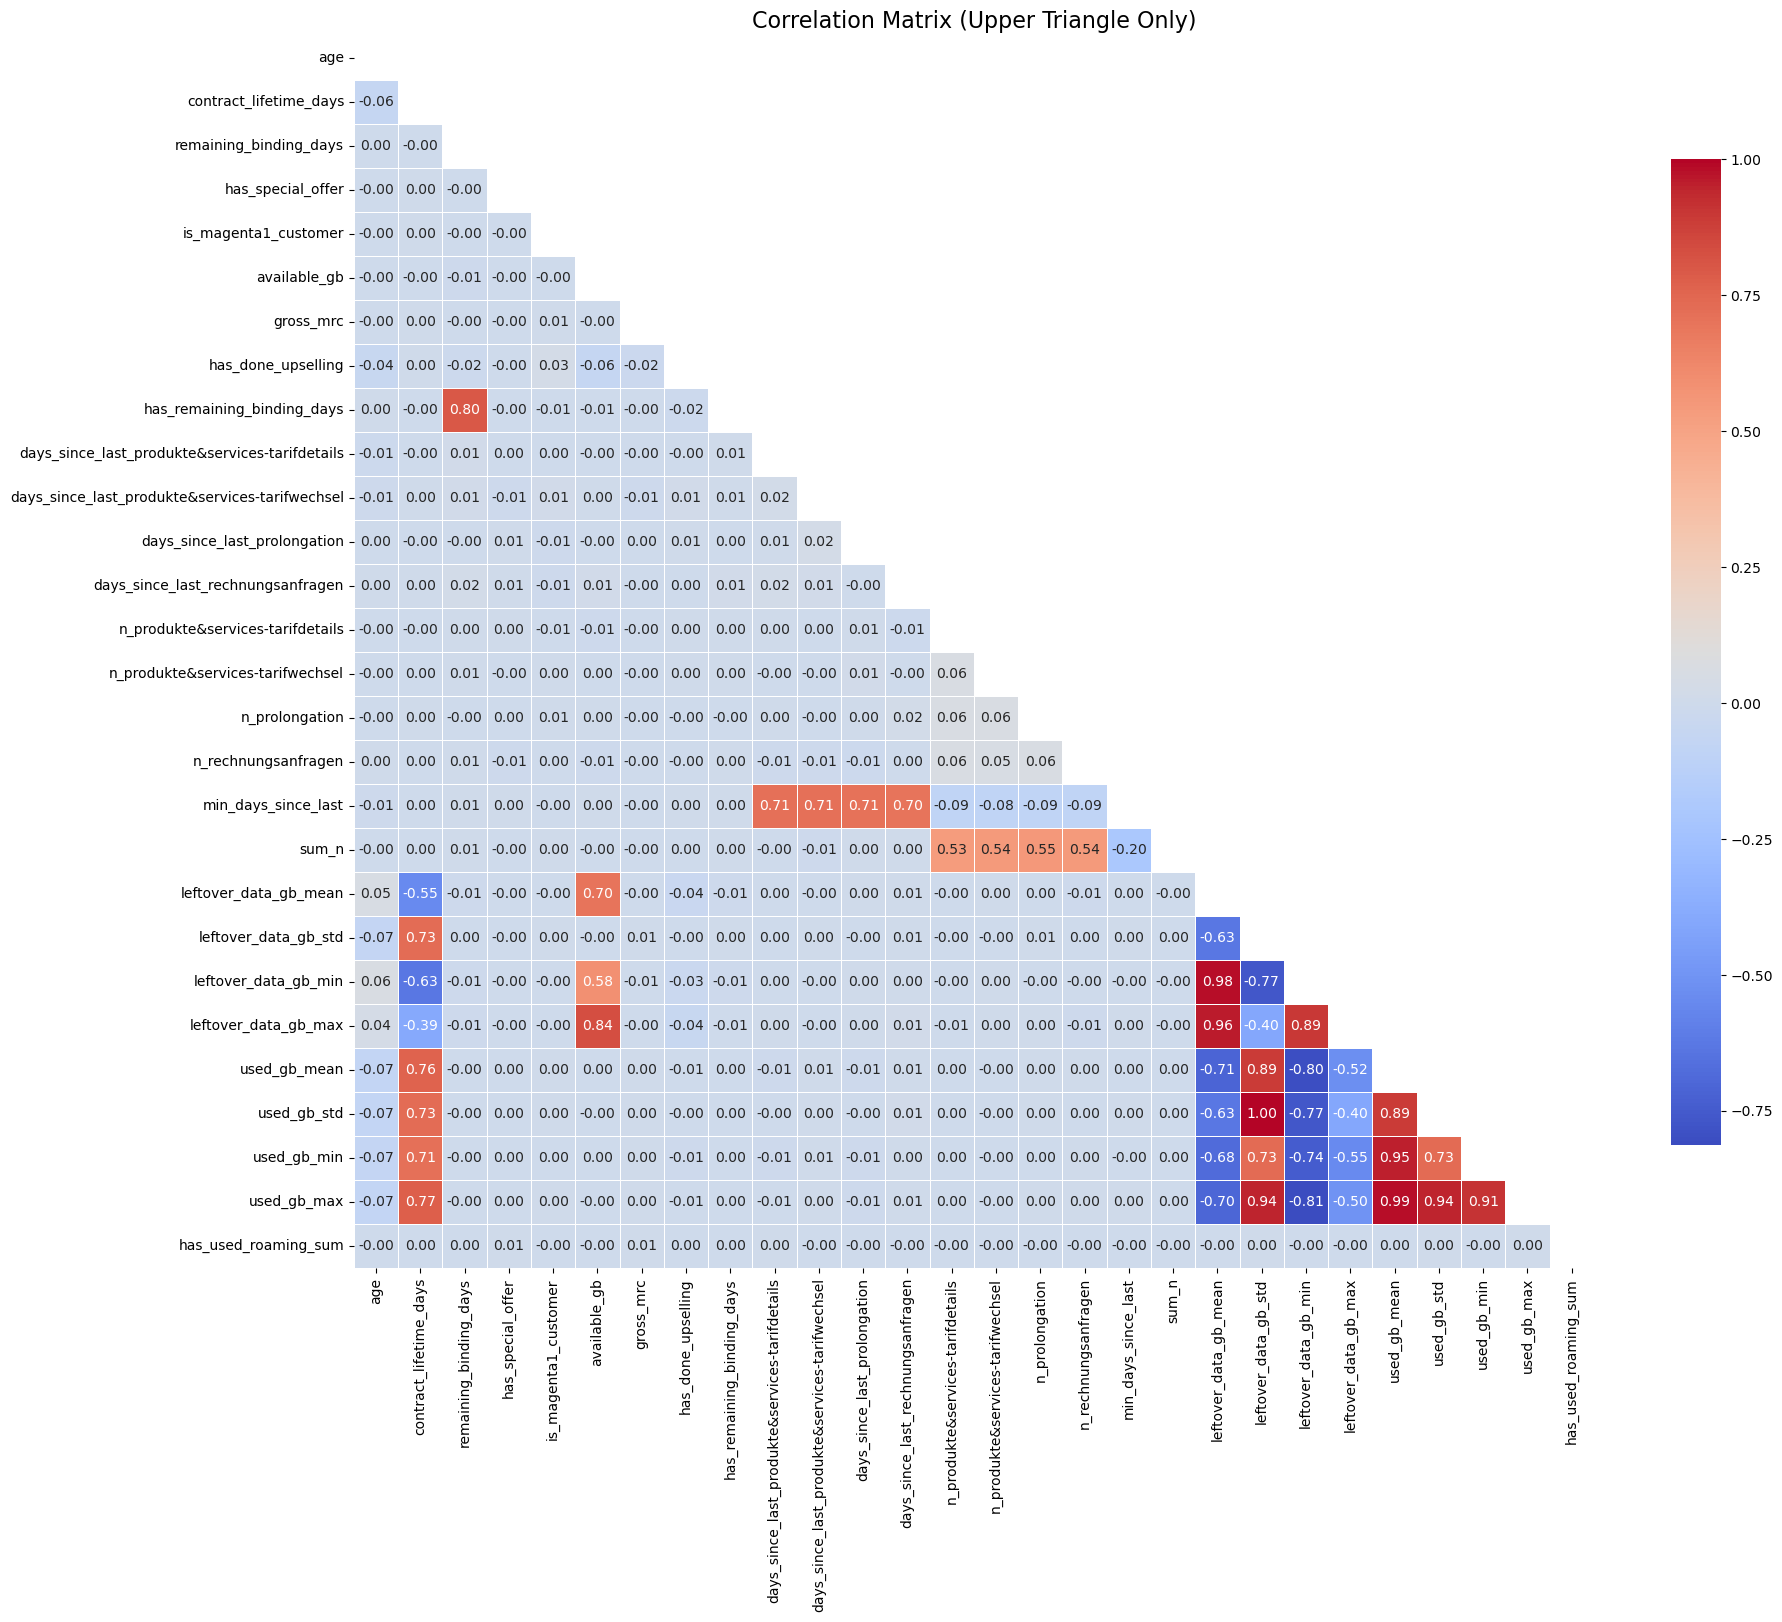

In [21]:
# Select numeric columns, exclude any column with 'id'
numeric_data = merged_data.select_dtypes(include="number").drop(
    columns=[col for col in merged_data.columns if "id" in col.lower()],
    errors="ignore"
)

# Compute correlation matrix
corr_matrix = numeric_data.corr()

# Create a mask for the upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Set up the matplotlib figure
plt.figure(figsize=(20, 16))

# Draw the heatmap with the mask
sns.heatmap(
    corr_matrix, 
    mask=mask, 
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm", 
    cbar_kws={"shrink": 0.8},
    linewidths=0.5
)

plt.title("Correlation Matrix (Upper Triangle Only)", fontsize=16)
plt.show()


In [22]:
import pandas as pd
from sklearn.feature_selection import mutual_info_classif
from sklearn.impute import SimpleImputer

# 1. Split features and target
X = merged_data.drop(columns=['customer_id', 'rating_account_id', 'has_done_upselling'])
y = merged_data['has_done_upselling']

# 2. Separate numeric and categorical columns
num_cols = X.select_dtypes(include='number').columns
cat_cols = X.select_dtypes(exclude='number').columns

# 3. Impute missing values
num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

X_num = pd.DataFrame(num_imputer.fit_transform(X[num_cols]), columns=num_cols)
X_cat = pd.DataFrame(cat_imputer.fit_transform(X[cat_cols]), columns=cat_cols)

# 4. One-hot encode categorical features
X_cat_encoded = pd.get_dummies(X_cat, drop_first=True)

# 5. Combine numeric + encoded categorical features
X_final = pd.concat([X_num, X_cat_encoded], axis=1)

# 6. Compute mutual information
mi = mutual_info_classif(X_final, y, discrete_features='auto')

# 7. Display sorted results
mi_series = pd.Series(mi, index=X_final.columns).sort_values(ascending=False)
print(mi_series.head(10))


has_remaining_binding_days                        0.013303
smartphone_brand_iPhone                           0.009814
days_since_last_rechnungsanfragen                 0.009608
days_since_last_produkte&services-tarifwechsel    0.009359
days_since_last_produkte&services-tarifdetails    0.009269
days_since_last_prolongation                      0.008630
smartphone_brand_Samsung                          0.006943
has_used_roaming_sum                              0.006637
available_gb                                      0.005053
is_magenta1_customer                              0.004701
dtype: float64


Correlation Matrix:
While nothing seems to be correlated to the target variable (most probably due to the class imbalance which ) has_done_upselling there are some correlations present between the features themselves.

- not surprisingly the used_gb and leftover_gb metrics are highly correlated since they are mathematically dependent on each other. The same holds true for the interaction metrics with their aggregated counterparts sum_n and min_days_since_last as well as the has_remaining_binding_days column and its counterpart remaining_binding_days.
- furthermore there seems to be a correlation between the contract_lifetime_days and the used_gb / leftover_data_gb columns. People with higher contract lifetimes tend to use more gb and have less leftover gb at the end of the month. 

mutual_info_classif:
There seems to be some weak relationship between the target variable and some of the customer interaction data and the binary binding days variable, especially with:
- days_since_last_prolongation
- has_remaining_binding_days
- days_since_last_produkte&services-tarifdetails 
- days_since_last_rechnungsanfragen

knowing any of these variables gives "weak" information about what value has_done_upselling might be. 